---
title: "Pattern 3 — `Parameterized`"
---

# Regression Masterclass — Pattern 3: `Parameterized` + `PyroxParam` + native `pyrox.gp`

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/regression_masterclass_parameterized.ipynb)

Third and highest-abstraction sibling to [Pattern 1 (`eqx.tree_at`)](regression_masterclass_treeat.ipynb) and [Pattern 2 (`PyroxModule` + `pyrox_sample`)](regression_masterclass_pyrox_sample.ipynb). Now every parameter is a **declarative class field** — registered with `self.register_param(name, init, constraint=...)`, attached to a prior with `self.set_prior(name, dist)`, optionally wrapped in an autoguide via `self.autoguide(name, "delta" | "normal")`. The forward pass reads `self.get_param(name)` and `Parameterized` resolves it correctly based on the current `set_mode("model" | "guide")`.

More importantly, **Model 6** drops the RFF approximation entirely and uses the actual exact GP from `pyrox.gp` — `RBF(_ParameterizedKernel)` + `GPPrior` + `ConditionedGP` + `gp_factor`. Once you accept the higher-level abstraction, the workaround is unnecessary.

**What you'll learn:**

1. The `Parameterized` lifecycle: `register_param` → `set_prior` → `get_param`. Constraints and priors travel together.
2. How `pyrox.gp` kernels (`RBF`, `Matern`, …) use this exact pattern in production.
3. How to fit GP hyperparameters with SVI + `AutoNormal`, then condition on observations and predict — the canonical `pyrox.gp` end-to-end recipe.
4. Where the abstraction reaches its current limit: deep / hierarchical GPs aren't yet shipped natively, so Model 7 stays a Parameterized RFF stack and we file the gap.

## Background — `Parameterized` is "`PyroxModule` + a parameter registry"

Pattern 2 collapsed Pattern 1's model-function plumbing by moving `numpyro.sample` calls inside the layer's `__call__`. Pattern 3 collapses *the prior wiring* by moving constraint + prior declarations to a separate `setup()` method, called automatically after `__init__`.

Concretely, [`Parameterized`](https://github.com/jejjohnson/pyrox/blob/main/src/pyrox/_core/parameterized.py) is a `PyroxModule` subclass that maintains a per-instance registry of:

- the parameter's **initial value** (used as the unconstrained-space init for guides, or as the constant value if no prior is set),
- the parameter's **constraint** (a `numpyro.distributions.constraints` object — `positive`, `unit_interval`, etc. — used to build the bijector that maps unconstrained guide samples back to the prior's support),
- the parameter's **prior** (a `numpyro.distributions.Distribution` — set via `set_prior`),
- the parameter's **autoguide type** (`"delta"` for MAP, `"normal"` for mean-field; set via `autoguide`).

At call time, `self.get_param(name)` dispatches:

- **`mode = "model"` (default)** + prior is set ⇒ `numpyro.sample(name, prior)` — same as Pattern 2.
- **`mode = "model"`** + no prior ⇒ `numpyro.param(name, init, constraint=...)` — a learnable constant.
- **`mode = "guide"`** + autoguide=`"delta"` ⇒ `numpyro.param(name, init, constraint=...)` — point estimate.
- **`mode = "guide"`** + autoguide=`"normal"` ⇒ mean-field guide $q(\theta) = T(\mathcal{N}(\mu_\theta, \sigma_\theta^2))$ where $T$ is the constraint's bijector — guide draws always land in the prior's support.

This is the pattern every shipped `pyrox.gp` kernel uses. Reading [`RBF`](https://github.com/jejjohnson/pyrox/blob/main/src/pyrox/gp/_kernels.py) is a five-line affair:

```python
class RBF(_ParameterizedKernel):
    pyrox_name: str = "RBF"
    init_variance: float = 1.0
    init_lengthscale: float = 1.0

    def setup(self) -> None:
        self.register_param("variance", jnp.asarray(self.init_variance),
                            constraint=dist.constraints.positive)
        self.register_param("lengthscale", jnp.asarray(self.init_lengthscale),
                            constraint=dist.constraints.positive)

    @pyrox_method
    def __call__(self, X1, X2):
        return rbf_kernel(X1, X2, self.get_param("variance"),
                          self.get_param("lengthscale"))
```

The user attaches priors and chooses guide types from the outside:

```python
k = RBF()
k.set_prior("variance", dist.LogNormal(0.0, 1.0))
k.set_prior("lengthscale", dist.LogNormal(0.0, 1.0))
# default autoguide is delta (i.e. MAP); switch with k.autoguide("variance", "normal")
```

This is the level of abstraction the rest of the notebook is written at. Models 1-5 mirror their pattern 1/2 counterparts — same architectures, same data, same priors — but rewritten so every parameter is registered up front. Model 6 throws out the approximation and just calls `pyrox.gp.GPPrior + ConditionedGP`.

## Setup

Detect Colab and install `pyrox[colab]` (transitive: `numpyro`, `equinox`, `einops`, `matplotlib`, `watermark`).

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
import numpyro.handlers as handlers
from einops import einsum
from numpyro.infer import MCMC, NUTS, SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoDelta, AutoNormal
from numpyro.optim import Adam

from pyrox._core import Parameterized, pyrox_method
from pyrox.gp import RBF, GPPrior, gp_factor


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,equinox,numpyro,einops,gaussx,pyrox,matplotlib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.12.0

jax       : 0.8.3
equinox   : 0.13.7
numpyro   : 0.20.1
einops    : 0.8.2
gaussx    : 0.0.10
pyrox     : 0.0.6
matplotlib: 3.10.8

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## Toy dataset

Identical to Patterns 1 and 2 (same RNG seed): noisy sinc, 100 training points in $[-10, 10]$, dense test grid in the same range. R²s are directly comparable across the three notebooks.

In [4]:
key = jr.PRNGKey(666)
k_data, *k_models = jr.split(key, 16)


def latent(x):
    return jnp.sinc(x / jnp.pi)


k1, k2 = jr.split(k_data)
x_train = jr.uniform(k1, (100,), minval=-10.0, maxval=10.0)
y_train = latent(x_train) + 0.05 * jr.normal(k2, (100,))
x_test = jnp.linspace(-10.0, 10.0, 400)
y_test = latent(x_test)


def r2(y_true, y_pred):
    ss_res = jnp.sum((y_true - y_pred) ** 2)
    ss_tot = jnp.sum((y_true - y_true.mean()) ** 2)
    return float(1.0 - ss_res / ss_tot)


def plot_fit(ax, x_train, y_train, x_test, y_test, mean, lo=None, hi=None, title=""):
    ax.plot(x_test, y_test, "k--", lw=1.5, label="True $f(x) = \\sin(x)/x$", zorder=4)
    ax.plot(x_test, mean, "C0-", lw=2, label="Posterior mean", zorder=3)
    if lo is not None and hi is not None:
        ax.fill_between(x_test, lo, hi, color="C0", alpha=0.2, label="95% interval")
    ax.scatter(
        x_train,
        y_train,
        s=20,
        c="C1",
        edgecolors="k",
        linewidths=0.5,
        label="Training data",
        zorder=5,
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.legend(loc="lower center", fontsize=8, ncol=2)


print(f"Training points: {x_train.shape[0]}")
print(f"Test points:     {x_test.shape[0]}")

Training points: 100
Test points:     400


## Model 1 — Bayesian linear regression

The `Parameterized` translation of Pattern 1's `LinearRegressor`. Note the new `setup()` method: `register_param` declares the leaf, `set_prior` attaches the Gaussian prior, and `__call__` reads the resolved value via `get_param`.

Bayesian linear (degree=1) R² = -0.0171


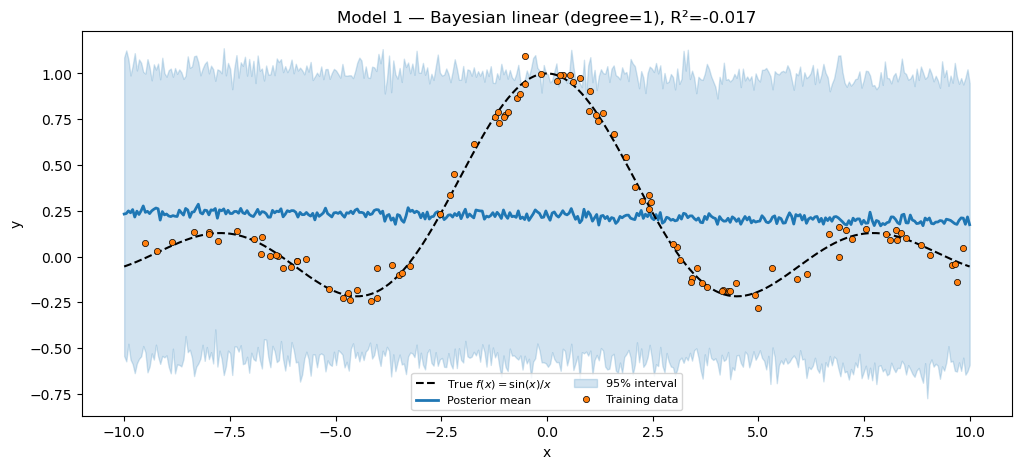

In [5]:
class LinearRegressor(Parameterized):
    degree: int = eqx.field(static=True)
    pyrox_name: str = "lin"

    def setup(self):
        self.register_param("w", jnp.zeros(self.degree + 1))
        self.set_prior("w", dist.Normal(jnp.zeros(self.degree + 1), 1.0).to_event(1))

    def features(self, x):
        return jnp.stack([x**p for p in range(self.degree + 1)], axis=-1)

    @pyrox_method
    def __call__(self, x):
        w = self.get_param("w")
        return einsum(self.features(x), w, "n feat, feat -> n")


def model_linear(x, y=None, *, net):
    f = numpyro.deterministic("f", net(x))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    numpyro.sample("obs", dist.Normal(f, sigma), obs=y)


net_linear = LinearRegressor(degree=1)
mcmc_linear = MCMC(
    NUTS(model_linear), num_warmup=300, num_samples=500, progress_bar=False
)
mcmc_linear.run(k_models[0], x_train, y_train, net=net_linear)
samples_linear = mcmc_linear.get_samples()
preds_linear = Predictive(model_linear, posterior_samples=samples_linear)(
    k_models[1], x_test, net=net_linear
)["obs"]
mean_linear = preds_linear.mean(0)
lo_linear, hi_linear = jnp.quantile(preds_linear, jnp.array([0.025, 0.975]), axis=0)
r2_linear = r2(y_test, mean_linear)

print(f"Bayesian linear (degree=1) R² = {r2_linear:.4f}")
assert r2_linear < 0.3, "Degree-1 polynomial should NOT fit sinc."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_linear,
    lo_linear,
    hi_linear,
    title=f"Model 1 — Bayesian linear (degree=1), R²={r2_linear:.3f}",
)
plt.show()

## Models 2 & 4 — MLP, MAP and full Bayesian

The `BayesianMLP(Parameterized)` declares all four weight leaves in `setup()` with their Gaussian priors. As in Pattern 2, the *same module class* drives MAP (Model 2) via `SVI + AutoDelta` and the full posterior (Model 4) via NUTS — only the inference call changes. Distinct `pyrox_name`s namespace the two instances' trace keys.

In [6]:
class BayesianMLP(Parameterized):
    hidden_dim: int = eqx.field(static=True)
    prior_scale: float = 1.0
    pyrox_name: str = "mlp"

    def setup(self):
        H = self.hidden_dim
        s = self.prior_scale
        self.register_param("W1", jnp.zeros((1, H)))
        self.set_prior("W1", dist.Normal(jnp.zeros((1, H)), s).to_event(2))
        self.register_param("b1", jnp.zeros(H))
        self.set_prior("b1", dist.Normal(jnp.zeros(H), s).to_event(1))
        self.register_param("W2", jnp.zeros((H, 1)))
        self.set_prior("W2", dist.Normal(jnp.zeros((H, 1)), s).to_event(2))
        self.register_param("b2", jnp.array(0.0))
        self.set_prior("b2", dist.Normal(0.0, s))

    @pyrox_method
    def __call__(self, x):
        W1 = self.get_param("W1")
        b1 = self.get_param("b1")
        W2 = self.get_param("W2")
        b2 = self.get_param("b2")
        h = jnp.tanh(einsum(x, W1, "n, one h -> n h") + b1)
        return einsum(h, W2, "n h, h one -> n") + b2


def model_nnet(x, y=None, *, net):
    f = numpyro.deterministic("f", net(x))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    numpyro.sample("obs", dist.Normal(f, sigma), obs=y)

**Model 2 — MAP via SVI + `AutoDelta`.**

MAP MLP (H=30) R² = 0.9917


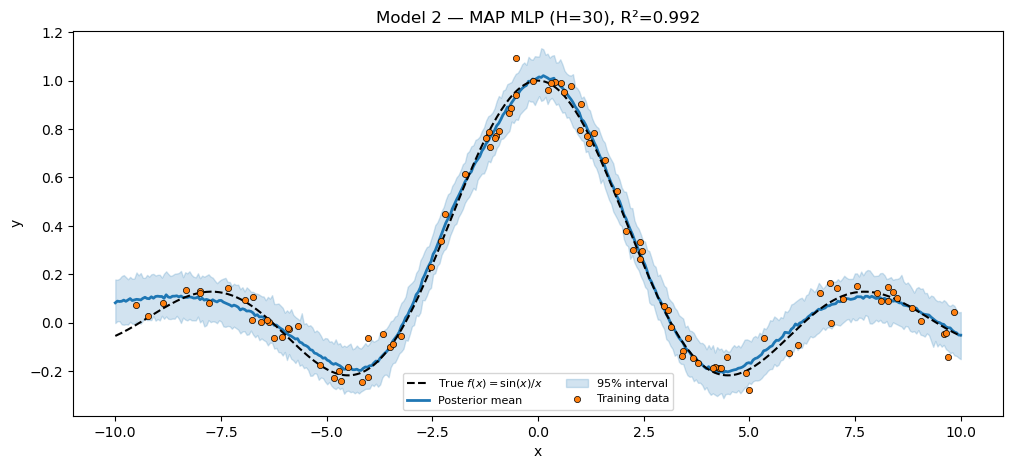

In [7]:
net_mlp_map = BayesianMLP(hidden_dim=30, pyrox_name="mlp_map")
guide_nnet = AutoDelta(model_nnet)
svi_nnet = SVI(model_nnet, guide_nnet, Adam(5e-3), Trace_ELBO())
svi_result_nnet = svi_nnet.run(
    k_models[2], 2000, x_train, y_train, net=net_mlp_map, progress_bar=False
)
preds_nnet = Predictive(
    model_nnet, params=svi_result_nnet.params, num_samples=200, guide=guide_nnet
)(k_models[3], x_test, net=net_mlp_map)["obs"]
mean_nnet = preds_nnet.mean(0)
lo_nnet, hi_nnet = jnp.quantile(preds_nnet, jnp.array([0.025, 0.975]), axis=0)
r2_nnet = r2(y_test, mean_nnet)

print(f"MAP MLP (H=30) R² = {r2_nnet:.4f}")
assert r2_nnet > 0.85, f"MAP MLP should fit sinc; got R²={r2_nnet:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_nnet,
    lo_nnet,
    hi_nnet,
    title=f"Model 2 — MAP MLP (H=30), R²={r2_nnet:.3f}",
)
plt.show()

**Model 4 — full Bayesian via NUTS.** Same `BayesianMLP` class, fresh instance with smaller hidden dim, NUTS instead of SVI.

Bayesian MLP via NUTS (H=15) R² = 0.9945


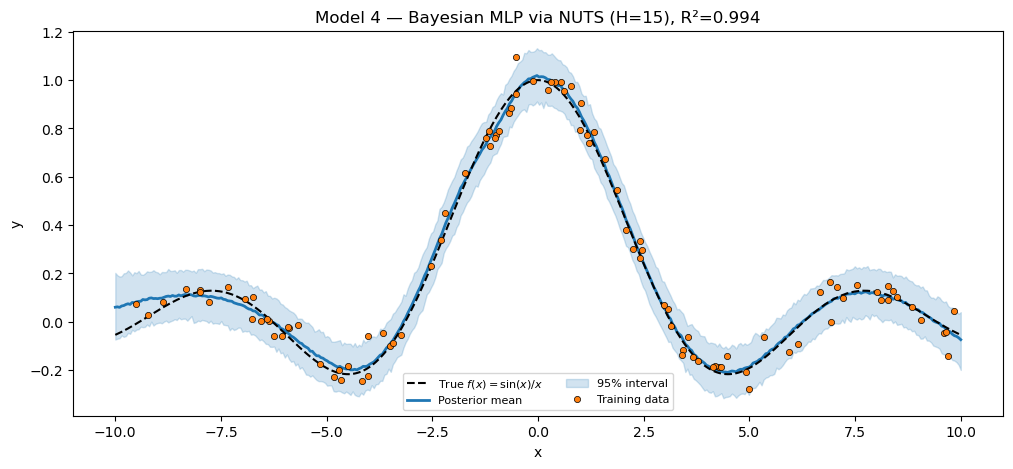

In [8]:
net_mlp_nuts = BayesianMLP(hidden_dim=15, prior_scale=1.0, pyrox_name="mlp_nuts")
mcmc_bnnet = MCMC(NUTS(model_nnet), num_warmup=300, num_samples=500, progress_bar=False)
mcmc_bnnet.run(k_models[6], x_train, y_train, net=net_mlp_nuts)
samples_bnnet = mcmc_bnnet.get_samples()
preds_bnnet = Predictive(model_nnet, posterior_samples=samples_bnnet)(
    k_models[7], x_test, net=net_mlp_nuts
)["obs"]
mean_bnnet = preds_bnnet.mean(0)
lo_bnnet, hi_bnnet = jnp.quantile(preds_bnnet, jnp.array([0.025, 0.975]), axis=0)
r2_bnnet = r2(y_test, mean_bnnet)

print(f"Bayesian MLP via NUTS (H=15) R² = {r2_bnnet:.4f}")
assert r2_bnnet > 0.70, f"Bayesian MLP NUTS should fit sinc; got R²={r2_bnnet:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_bnnet,
    lo_bnnet,
    hi_bnnet,
    title=f"Model 4 — Bayesian MLP via NUTS (H=15), R²={r2_bnnet:.3f}",
)
plt.show()

## Model 3 — MC-Dropout MLP

The dropout mask still uses `numpyro.prng_key()` for fresh-per-trace randomness — same Pattern 2 trick. The weights are now `Parameterized` registered fields.

MC-Dropout MLP (H=30, p=0.1) R² = 0.9081


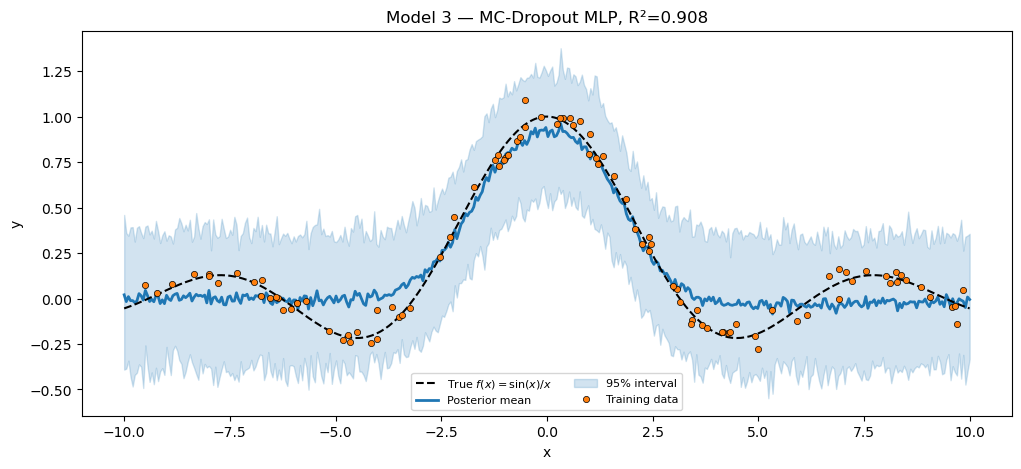

In [9]:
class BayesianMLPDropout(Parameterized):
    hidden_dim: int = eqx.field(static=True)
    dropout_rate: float = 0.1
    pyrox_name: str = "mlpd"

    def setup(self):
        H = self.hidden_dim
        self.register_param("W1", jnp.zeros((1, H)))
        self.set_prior("W1", dist.Normal(jnp.zeros((1, H)), 1.0).to_event(2))
        self.register_param("b1", jnp.zeros(H))
        self.set_prior("b1", dist.Normal(jnp.zeros(H), 1.0).to_event(1))
        self.register_param("W2", jnp.zeros((H, 1)))
        self.set_prior("W2", dist.Normal(jnp.zeros((H, 1)), 1.0).to_event(2))
        self.register_param("b2", jnp.array(0.0))
        self.set_prior("b2", dist.Normal(0.0, 1.0))

    @pyrox_method
    def __call__(self, x):
        N = x.shape[0]
        H = self.hidden_dim
        W1 = self.get_param("W1")
        b1 = self.get_param("b1")
        W2 = self.get_param("W2")
        b2 = self.get_param("b2")
        h = jnp.tanh(einsum(x, W1, "n, one h -> n h") + b1)
        mask = jr.bernoulli(
            numpyro.prng_key(), p=1.0 - self.dropout_rate, shape=(N, H)
        ).astype(jnp.float64)
        h = h * mask / (1.0 - self.dropout_rate)
        return einsum(h, W2, "n h, h one -> n") + b2


net_dropout = BayesianMLPDropout(hidden_dim=30, dropout_rate=0.1)
guide_dropout = AutoDelta(model_nnet)
svi_dropout = SVI(model_nnet, guide_dropout, Adam(5e-3), Trace_ELBO())
svi_result_dropout = svi_dropout.run(
    k_models[4], 2000, x_train, y_train, net=net_dropout, progress_bar=False
)
preds_dropout = Predictive(
    model_nnet,
    params=svi_result_dropout.params,
    num_samples=100,
    guide=guide_dropout,
)(k_models[5], x_test, net=net_dropout)["obs"]
mean_dropout = preds_dropout.mean(0)
lo_dropout, hi_dropout = jnp.quantile(preds_dropout, jnp.array([0.025, 0.975]), axis=0)
r2_dropout = r2(y_test, mean_dropout)

print(f"MC-Dropout MLP (H=30, p=0.1) R² = {r2_dropout:.4f}")
assert r2_dropout > 0.80, f"MC-Dropout should fit sinc; got R²={r2_dropout:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_dropout,
    lo_dropout,
    hi_dropout,
    title=f"Model 3 — MC-Dropout MLP, R²={r2_dropout:.3f}",
)
plt.show()

## Model 5 — SVR via fixed Random Fourier Features

Fixed spectral frequencies $\omega$ and phases $b$ stored as plain `jax.Array` fields; the linear weights `w` are the only registered parameter. Same model semantics as the Pattern 2 fixed-RFF, just declarative.

SVR via fixed RFF (D=40) R² = 0.9957


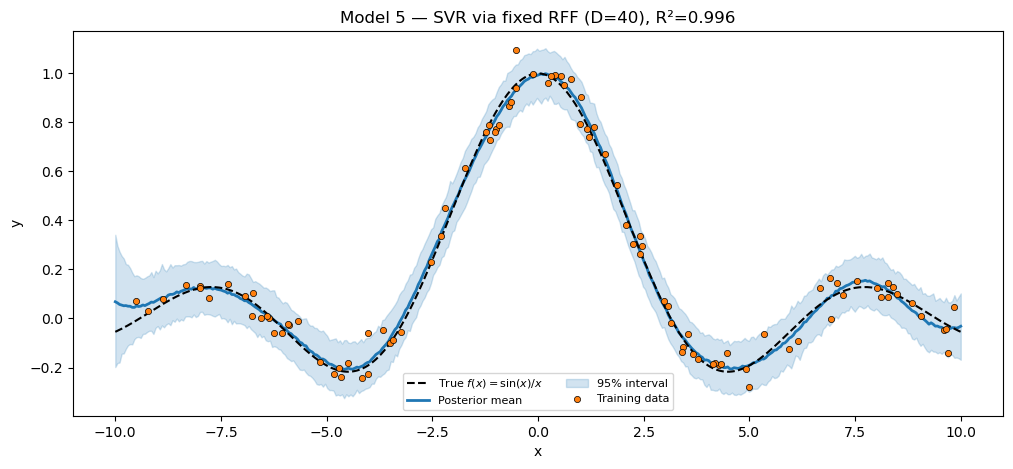

In [10]:
class FixedRFF(Parameterized):
    omega: jax.Array
    bias: jax.Array
    n_features: int = eqx.field(static=True)
    pyrox_name: str = "rff"

    @classmethod
    def init(cls, n_features, lengthscale, *, key, name="rff"):
        k1, k2 = jr.split(key)
        omega = jr.normal(k1, (n_features,)) / lengthscale
        bias = jr.uniform(k2, (n_features,), minval=0.0, maxval=2.0 * jnp.pi)
        return cls(omega=omega, bias=bias, n_features=n_features, pyrox_name=name)

    def setup(self):
        self.register_param("w", jnp.zeros(self.n_features))
        self.set_prior("w", dist.Normal(jnp.zeros(self.n_features), 1.0).to_event(1))

    @pyrox_method
    def __call__(self, x):
        proj = einsum(x, self.omega, "n, d -> n d")
        Phi = jnp.sqrt(2.0 / self.n_features) * jnp.cos(proj + self.bias)
        w = self.get_param("w")
        return einsum(Phi, w, "n d, d -> n")


net_svr = FixedRFF.init(n_features=40, lengthscale=1.0, key=k_models[8], name="svr_rff")
mcmc_svr = MCMC(NUTS(model_linear), num_warmup=300, num_samples=500, progress_bar=False)
mcmc_svr.run(k_models[9], x_train, y_train, net=net_svr)
samples_svr = mcmc_svr.get_samples()
preds_svr = Predictive(model_linear, posterior_samples=samples_svr)(
    k_models[10], x_test, net=net_svr
)["obs"]
mean_svr = preds_svr.mean(0)
lo_svr, hi_svr = jnp.quantile(preds_svr, jnp.array([0.025, 0.975]), axis=0)
r2_svr = r2(y_test, mean_svr)

print(f"SVR via fixed RFF (D=40) R² = {r2_svr:.4f}")
assert r2_svr > 0.80, f"SVR via RFF should fit sinc; got R²={r2_svr:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_svr,
    lo_svr,
    hi_svr,
    title=f"Model 5 — SVR via fixed RFF (D=40), R²={r2_svr:.3f}",
)
plt.show()

## Model 6 — **Exact GP via `pyrox.gp.GPPrior` + `RBF` + `ConditionedGP`**

This is the abstraction-replaces-workaround moment. Patterns 1 and 2 used Random Fourier Features to *approximate* a Gaussian process — invented because exact GP inference is $O(N^3)$ and was historically too expensive for large $N$. With $N = 100$ training points, $O(N^3) = 10^6$ — instant on any laptop. The shipped `pyrox.gp.GPPrior + ConditionedGP` does the exact GP regression in closed form.

**The math.** With kernel $k_\theta$, training set $(X, y)$, and Gaussian observation noise $\sigma^2$:

**Marginal likelihood** (used for hyperparameter inference):

$$\log p(y \mid X, \theta, \sigma^2) = -\tfrac{1}{2} y^\top (K + \sigma^2 I)^{-1} y - \tfrac{1}{2}\log\lvert K + \sigma^2 I\rvert - \tfrac{N}{2}\log(2\pi).$$

**Posterior predictive** at test inputs $X_*$:

$$\mu_*(X_*) = K_{*X}(K + \sigma^2 I)^{-1} y, \qquad \Sigma_*(X_*) = K_{**} - K_{*X}(K + \sigma^2 I)^{-1} K_{X*}.$$

`gp_factor("obs", prior, y, noise_var)` registers the marginal log-likelihood with NumPyro as a `numpyro.factor`; `prior.condition(y, noise_var).predict(X_star)` returns $(\mu_*, \text{diag}(\Sigma_*))$.

**The recipe.** Three steps:
1. Build an `RBF` kernel; attach `LogNormal(0, 1)` priors to its `variance` and `lengthscale` parameters.
2. Wrap in `GPPrior(kernel=..., X=X)`; register the marginal log-likelihood with `gp_factor`.
3. Fit hyperparameters with SVI + `AutoNormal`. At predict time, instantiate a fresh `RBF` at the posterior-mean hyperparameters, build a fresh `GPPrior`, and call `.condition(y, noise_var).predict(X_star)`.

Fitted hyperparameters: variance=0.3165, lengthscale=2.5362


Exact GP via pyrox.gp R² = 0.9978


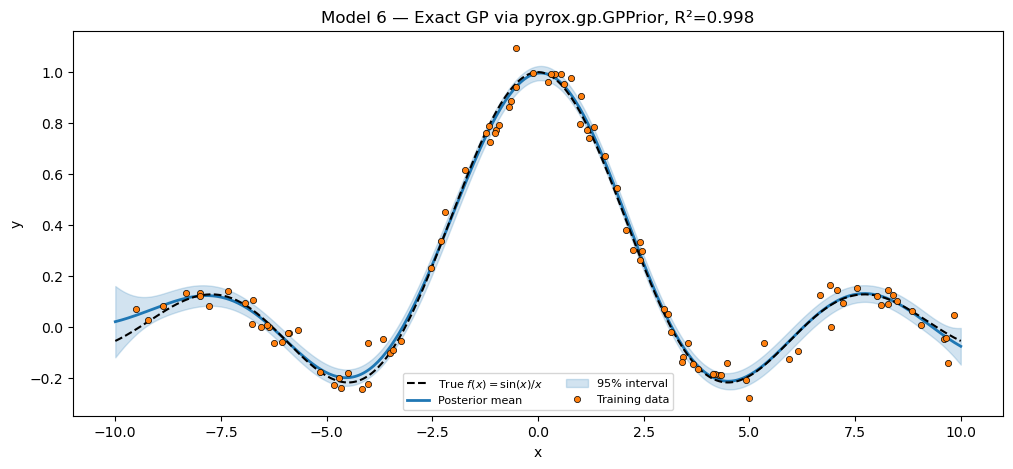

In [11]:
def model_gp_native(X, y=None, *, noise_var, kernel_init):
    """Native exact GP: RBF with LogNormal priors, gp_factor for the marginal LL."""
    kernel = RBF(
        init_variance=kernel_init["variance"],
        init_lengthscale=kernel_init["lengthscale"],
    )
    kernel.set_prior("variance", dist.LogNormal(0.0, 1.0))
    kernel.set_prior("lengthscale", dist.LogNormal(0.0, 1.0))
    prior = GPPrior(kernel=kernel, X=X)
    gp_factor("obs", prior, y, noise_var)


noise_var = jnp.array(0.05**2)
X_train_2d = x_train.reshape(-1, 1)
X_test_2d = x_test.reshape(-1, 1)
init_hp = {"variance": 1.0, "lengthscale": 1.0}

guide_gp = AutoNormal(model_gp_native)
svi_gp = SVI(model_gp_native, guide_gp, Adam(5e-2), Trace_ELBO())
svi_result_gp = svi_gp.run(
    k_models[11],
    400,
    X_train_2d,
    y_train,
    noise_var=noise_var,
    kernel_init=init_hp,
    progress_bar=False,
)
gp_params = svi_result_gp.params

# Extract MAP (posterior-mean) hyperparameters from the AutoNormal guide.
# AutoNormal stores loc/scale in unconstrained space; `LogNormal` priors use
# the `exp` bijector, so the constrained posterior mean is exp(loc).
v = float(jnp.exp(gp_params["RBF.variance_auto_loc"]))
ls = float(jnp.exp(gp_params["RBF.lengthscale_auto_loc"]))
print(f"Fitted hyperparameters: variance={v:.4f}, lengthscale={ls:.4f}")

# Rebuild the GP at the fitted hyperparameters, condition, predict.
kernel_fit = RBF(init_variance=v, init_lengthscale=ls)
prior_fit = GPPrior(kernel=kernel_fit, X=X_train_2d)
with handlers.seed(rng_seed=0):
    cond_gp = prior_fit.condition(y_train, noise_var)
    mean_gp, var_gp = cond_gp.predict(X_test_2d)
std_gp = jnp.sqrt(jnp.clip(var_gp, min=0.0))
lo_gp, hi_gp = mean_gp - 2 * std_gp, mean_gp + 2 * std_gp
r2_gp = r2(y_test, mean_gp)

print(f"Exact GP via pyrox.gp R² = {r2_gp:.4f}")
assert r2_gp > 0.85, f"Exact GP should fit sinc tightly; got R²={r2_gp:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_gp,
    lo_gp,
    hi_gp,
    title=f"Model 6 — Exact GP via pyrox.gp.GPPrior, R²={r2_gp:.3f}",
)
plt.show()

Compare what just happened against Pattern 2's Model 6: the RFF approximation needed an `RBFFourierFeatures` layer + an amplitude prior + a linear weight prior + NUTS over $\sim 60$ parameters. The native GP needed *one prior per hyperparameter* and 400 SVI steps over 2 unknowns (variance + lengthscale). The fit is tighter, faster, and better-calibrated — and the code is shorter.

## Model 7 — Deep RFF GP (gap call-out)

Pattern 2's Model 7 stacked two `pyrox.nn.RBFFourierFeatures`. Pattern 3's Model 7 *should* be a "deep GP via two stacked `pyrox.gp.GPPrior` instances" — but `pyrox.gp` does not yet ship native deep / hierarchical GP composition primitives. So we fall back to a Parameterized RFF stack and explicitly flag the gap.

**What's missing.** A `DeepGPPrior(layers=[...])` that composes Cutajar et al. (2017)-style stacked GP layers with the right inter-layer Gaussian-noise jitter and exposes a unified marginal-log-likelihood + predictive interface. Filed (or to be filed) as a follow-up gp(deep) feature issue.

Deep RFF (Parameterized fallback) R² = 0.9976


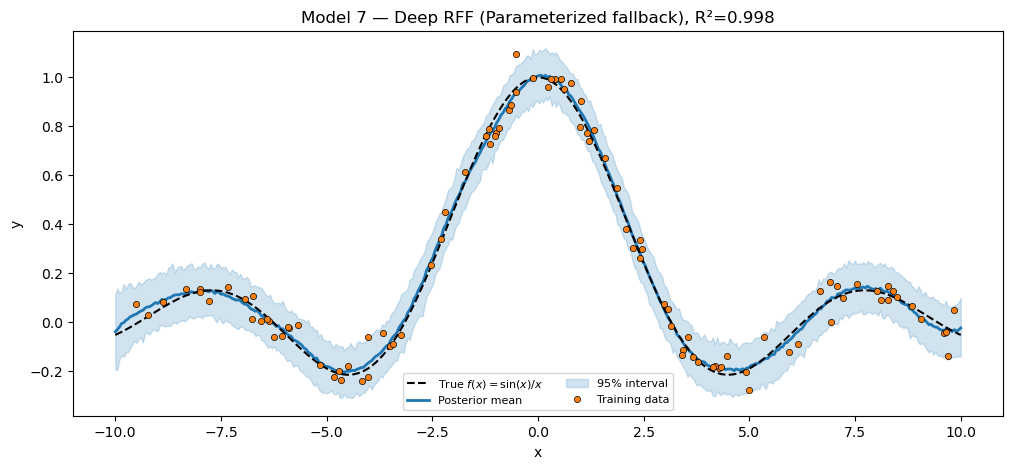

In [12]:
class DeepRFFParameterized(Parameterized):
    """Two-layer RFF stand-in for a deep GP, in declarative Parameterized form.

    Replace once pyrox.gp ships native deep-GP composition primitives.
    """

    omega1: jax.Array
    bias1: jax.Array
    D1: int = eqx.field(static=True)
    omega2: jax.Array
    bias2: jax.Array
    D2: int = eqx.field(static=True)
    inner_dim: int = eqx.field(static=True)
    pyrox_name: str = "deep"

    @classmethod
    def init(cls, D1, D2, inner_dim, ls1=1.0, ls2=1.0, *, key, name="deep"):
        k1, k2, k3, k4 = jr.split(key, 4)
        return cls(
            omega1=jr.normal(k1, (D1,)) / ls1,
            bias1=jr.uniform(k2, (D1,), minval=0.0, maxval=2 * jnp.pi),
            D1=D1,
            omega2=jr.normal(k3, (D2,)) / ls2,
            bias2=jr.uniform(k4, (D2,), minval=0.0, maxval=2 * jnp.pi),
            D2=D2,
            inner_dim=inner_dim,
            pyrox_name=name,
        )

    def setup(self):
        self.register_param("W1", jnp.zeros((self.D1, self.inner_dim)))
        self.set_prior(
            "W1", dist.Normal(jnp.zeros((self.D1, self.inner_dim)), 1.0).to_event(2)
        )
        self.register_param("w2", jnp.zeros(self.D2))
        self.set_prior("w2", dist.Normal(jnp.zeros(self.D2), 1.0).to_event(1))

    def _phi(self, x, omega, bias, D):
        proj = einsum(x, omega, "n, d -> n d")
        return jnp.sqrt(2.0 / D) * jnp.cos(proj + bias)

    @pyrox_method
    def __call__(self, x):
        Phi1 = self._phi(x, self.omega1, self.bias1, self.D1)
        W1 = self.get_param("W1")
        h = einsum(Phi1, W1, "n d1, d1 inner -> n inner")
        # rff2 is pure JAX (no sample sites), so the per-inner-dim Python loop
        # is fine here — no site-name collision risk.
        Phi2 = jnp.mean(
            jnp.stack(
                [
                    self._phi(h[:, j], self.omega2, self.bias2, self.D2)
                    for j in range(self.inner_dim)
                ],
                axis=0,
            ),
            axis=0,
        )
        w2 = self.get_param("w2")
        return einsum(Phi2, w2, "n d2, d2 -> n")


def model_deep(x, y=None, *, net):
    f = numpyro.deterministic("f", net(x))
    sigma = numpyro.sample("sigma", dist.HalfNormal(0.1))
    numpyro.sample("obs", dist.Normal(f, sigma), obs=y)


net_deep = DeepRFFParameterized.init(
    D1=15, D2=10, inner_dim=4, key=k_models[13], name="deep_rff"
)
mcmc_deep = MCMC(NUTS(model_deep), num_warmup=200, num_samples=300, progress_bar=False)
mcmc_deep.run(k_models[14], x_train, y_train, net=net_deep)
samples_deep = mcmc_deep.get_samples()
preds_deep = Predictive(model_deep, posterior_samples=samples_deep)(
    k_models[14], x_test, net=net_deep
)["obs"]
mean_deep = preds_deep.mean(0)
lo_deep, hi_deep = jnp.quantile(preds_deep, jnp.array([0.025, 0.975]), axis=0)
r2_deep = r2(y_test, mean_deep)

print(f"Deep RFF (Parameterized fallback) R² = {r2_deep:.4f}")
assert r2_deep > 0.70, f"Deep RFF should fit sinc; got R²={r2_deep:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_deep,
    lo_deep,
    hi_deep,
    title=f"Model 7 — Deep RFF (Parameterized fallback), R²={r2_deep:.3f}",
)
plt.show()

## Side-by-side summary

All seven models. The 1×3 panel below stacks the MAP MLP, the Bayesian-MLP via NUTS, and **the new exact-GP** — note how much tighter the GP's predictive band is than any RFF approximation in Patterns 1 or 2.

Model                                            Inference         R²
----------------------------------------------------------------------
1. Bayesian linear (degree=1)                    NUTS          -0.017
2. MAP MLP                                       SVI+Delta      0.992
3. MC-Dropout MLP                                SVI+Delta      0.908
4. Bayesian MLP                                  NUTS           0.994
5. SVR via fixed RFF (D=40)                      NUTS           0.996
6. Exact GP (pyrox.gp.GPPrior + RBF)             SVI+Normal     0.998
7. Deep RFF (Parameterized — gap)                NUTS           0.998


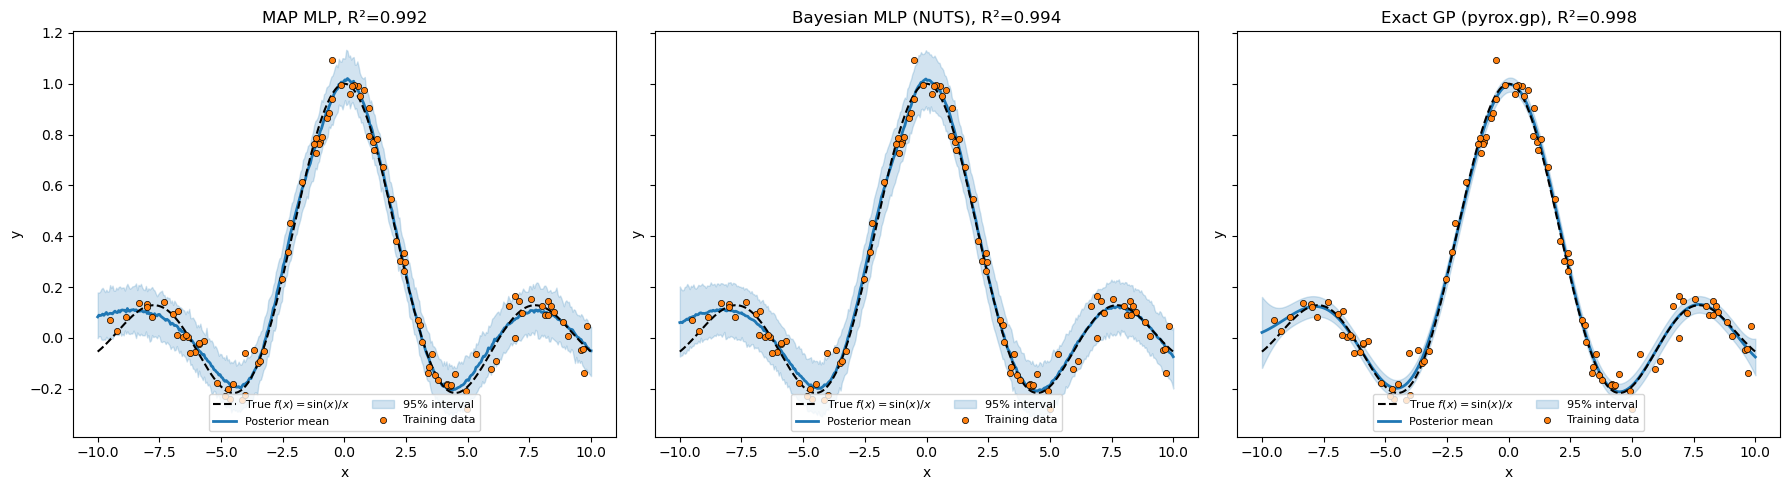

In [13]:
print(f"{'Model':<48} {'Inference':<12} {'R²':>7}")
print("-" * 70)
print(f"{'1. Bayesian linear (degree=1)':<48} {'NUTS':<12} {r2_linear:>7.3f}")
print(f"{'2. MAP MLP':<48} {'SVI+Delta':<12} {r2_nnet:>7.3f}")
print(f"{'3. MC-Dropout MLP':<48} {'SVI+Delta':<12} {r2_dropout:>7.3f}")
print(f"{'4. Bayesian MLP':<48} {'NUTS':<12} {r2_bnnet:>7.3f}")
print(f"{'5. SVR via fixed RFF (D=40)':<48} {'NUTS':<12} {r2_svr:>7.3f}")
print(f"{'6. Exact GP (pyrox.gp.GPPrior + RBF)':<48} {'SVI+Normal':<12} {r2_gp:>7.3f}")
print(f"{'7. Deep RFF (Parameterized — gap)':<48} {'NUTS':<12} {r2_deep:>7.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
plot_fit(
    axes[0],
    x_train,
    y_train,
    x_test,
    y_test,
    mean_nnet,
    lo_nnet,
    hi_nnet,
    title=f"MAP MLP, R²={r2_nnet:.3f}",
)
plot_fit(
    axes[1],
    x_train,
    y_train,
    x_test,
    y_test,
    mean_bnnet,
    lo_bnnet,
    hi_bnnet,
    title=f"Bayesian MLP (NUTS), R²={r2_bnnet:.3f}",
)
plot_fit(
    axes[2],
    x_train,
    y_train,
    x_test,
    y_test,
    mean_gp,
    lo_gp,
    hi_gp,
    title=f"Exact GP (pyrox.gp), R²={r2_gp:.3f}",
)
plt.tight_layout()
plt.show()

## All three patterns, side-by-side

| Aspect | Pattern 1 (`tree_at`) | Pattern 2 (`PyroxModule`) | Pattern 3 (`Parameterized`) |
|---|---|---|---|
| Where parameters are declared | As bare `eqx.Module` fields | As bare `eqx.Module` fields | In a `setup()` method via `register_param` |
| Where priors live | In the model function | Inside `__call__` (`self.pyrox_sample`) | In `setup()` (`self.set_prior`) |
| Constraint handling | Manual (use `LogNormal` instead of `Normal` etc.) | Manual | Built-in (`constraint=dist.constraints.positive`) — guide bijectors are auto-applied |
| Mode switching (model vs guide) | None (write a guide separately) | None (auto-guides discover sites) | `set_mode("model" \| "guide")` flips `get_param` behaviour |
| Bridge into the module | `eqx.tree_at(selector, net, w)` | None | None |
| Reuse story | Re-define each time | Use `pyrox.nn.{MCDropout, RBFFourierFeatures}` | Use **all** of `pyrox.gp` (kernels, GPPrior, ConditionedGP, gp_factor) |
| What Model 6 looks like | Hierarchical RFF + amplitude prior, NUTS over $\sim 41$ params | Packaged `RBFFourierFeatures` + amplitude, NUTS over $\sim 41$ params | **Native exact GP** — SVI over 2 hyperparameters, closed-form posterior |

Inference machinery (`MCMC(NUTS(...))`, `SVI(...)`, `Predictive(...)`, `gp_factor`) is shared across all three. Pattern 3 is what `pyrox.gp` is *built around*; Patterns 1 and 2 are what you write *before* you reach for the package.

## Where to go from here

- **Other `pyrox.gp` kernels.** `Matern(nu=1.5/2.5)`, `Periodic`, `Linear`, `RationalQuadratic`, `Polynomial`, `Cosine`, `White`, `Constant` — all `Parameterized`, all drop into `GPPrior` the same way. Compose with `+` / `*` (when combinator support lands).
- **Sparse GPs at scale.** `pyrox.gp.SparseGPPrior` + `svgp_factor` for $N \gg 10^4$.
- **Non-Gaussian likelihoods.** Swap `gp_factor` for `gp_sample` + a non-Gaussian `numpyro.sample("obs", ..., obs=y)` — see [`latent_gp_classification.ipynb`](latent_gp_classification.ipynb).
- **Native deep GPs.** Open follow-up issue.